# 12-lead ECG의 진단 상위 범주 다중 라벨 분류
**KY Medical AI Hub · v0.4 · Classification**

이 노트북은 데이터 다운로드, 변환, 학습, 평가, 결과 ZIP 저장까지 포함합니다.
**PTB-XL v1.0.3** — Official labels

### 먼저 확인
- 처음에는 `PROFILE=QUICK`로 위에서 아래까지 실행합니다. 경로를 직접 채우거나 원본 파일을 업로드할 필요 없이 다운로드하도록 작성했습니다.
- `1,000×12 leads`는 점검용 입력입니다. CLASSROOM은 `1,000×12 leads`입니다. 데이터 다운로드 크기와 모델 입력 크기는 다를 수 있습니다.
- **실제 원본 다운로드와 Google Colab 전체 실행은 아직 검증하지 않았습니다.** 정적 검사/합성 입력 테스트와 구분하세요. 외부 서버 장애·GPU 미배정·패키지 변경은 여전히 오류 원인입니다.
- 교육용 코드이며 임상 진단용이 아닙니다. 원내 환자 자료·API 키를 공개 GitHub에 올리지 마세요.

### 데이터와 이용 조건
공식 출처에서 학생 런타임으로 자동 다운로드합니다. 데이터 파일은 웹앱 ZIP이나 GitHub에 포함하지 않습니다. 필요한 100 Hz .hea/.dat만 받습니다. 500 Hz 전체 ZIP을 받지 않습니다.

[공식 출처/공식 다운로드 구현](https://physionet.org/content/ptb-xl/1.0.3/) · **CC BY 4.0**

### 분할
공식 환자 분리 fold 1–8/9/10을 train/val/test로 유지합니다. 정규화 평균·표준편차는 train에서만 계산합니다.

### 모델·평가
Small 1D CNN · Macro-F1 · label AUROC · Exact-match accuracy


In [14]:
#@title 1. 실습 설정
PROJECT_ID = 'ecg-multilabel'
SOURCE_URL = 'https://physionet.org/content/ptb-xl/1.0.3/'
DATA_LICENSE = 'CC BY 4.0'
TASK_FAMILY = 'classification'
DATA_KIND = 'ptbxl'
DATA_FLAG = ''
DIMENSIONS = 1
MODALITY = 'ECG'
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
MULTILABEL = True
ORDINAL = False
BINARY_TARGET = True
LABEL_MAP = {0:0,1:1,2:1}
CHANNELS = 3
MSD_TASK = ''
BOX_MODE = 'union'
VOLUME_CHANNEL = 0

PROFILE = "CLASSROOM" #@param ["QUICK", "CLASSROOM", "FULL"]
EPOCHS_OVERRIDE = 0 #@param {type:"integer"}
IMAGE_SIZE_OVERRIDE = 0 #@param {type:"integer"}
BATCH_SIZE_OVERRIDE = 0 #@param {type:"integer"}
SEED = 42 #@param {type:"integer"}
MAX_DOWNLOAD_GB = 6.0
# 위 override의 0은 기본값 사용입니다. FULL로 바꿔도 원본 해상도가 되지는 않습니다.
RESUME_CHECKPOINT = ""  # 생성 모델 재개 시 본인이 저장한 last_checkpoint.pt 경로
USE_GOOGLE_DRIVE = True #@param {type:"boolean"}

if PROFILE not in {"QUICK","CLASSROOM","FULL"}: raise ValueError("PROFILE 확인")
QUICK_RUN = PROFILE == "QUICK"
levels = {"QUICK":0,"CLASSROOM":1,"FULL":2}
level = levels[PROFILE]
# 표본 수와 해상도는 별도 설정입니다. ZIP 다운로드 용량은 표본 cap과 다를 수 있습니다.
if TASK_FAMILY == 'classification':
    EPOCHS = [3,15,30][level]
    CAPS = [dict(train=512,val=128,test=128),dict(train=5000,val=1000,test=1000),dict(train=None,val=None,test=None)][level]
    if DIMENSIONS==3:
        CAPS = [dict(train=128,val=32,test=32),dict(train=1000,val=200,test=200),dict(train=None,val=None,test=None)][level]
    BATCH_SIZE = 8 if DIMENSIONS==3 else 32
    MEDMNIST_SIZE = 28 if QUICK_RUN else 64
    IMAGE_SIZE = MEDMNIST_SIZE
elif TASK_FAMILY == 'segmentation':
    EPOCHS = [2,15,40][level]
    CAPS = ([dict(train=8,val=3,test=3),dict(train=40,val=10,test=10),dict(train=None,val=None,test=None)] if DIMENSIONS==3 else
            [dict(train=64,val=16,test=16),dict(train=400,val=100,test=100),dict(train=None,val=None,test=None)])[level]
    BATCH_SIZE = 1 if DIMENSIONS==3 else 8
    IMAGE_SIZE = 128 if QUICK_RUN else 256
    MEDMNIST_SIZE = None
elif TASK_FAMILY == 'detection':
    EPOCHS = [2,15,40][level]
    CAPS = [dict(train=32,val=8,test=8),dict(train=256,val=64,test=64),dict(train=None,val=None,test=None)][level]
    BATCH_SIZE = 2
    IMAGE_SIZE = 256 if QUICK_RUN else 512
    MEDMNIST_SIZE = None
else:
    EPOCHS = [3,50,100][level]
    CAPS = [dict(train=512,val=64,test=64),dict(train=4000,val=256,test=256),dict(train=None,val=None,test=None)][level]
    BATCH_SIZE = 32
    IMAGE_SIZE = 32 if QUICK_RUN else 64
    MEDMNIST_SIZE = 64 if DATA_KIND=='medmnist_generation' else None
VOLUME_SIZE = 48 if QUICK_RUN else 64
VOLUME_CAPS = [dict(train=8,val=3,test=3),dict(train=80,val=16,test=16),dict(train=None,val=None,test=None)][level]
SLICES_PER_VOLUME = [4,12,None][level]
DIFFUSION_STEPS = 200
LEARNING_RATE = 2e-4 if TASK_FAMILY in ('generation','detection') else 1e-3
DISPLAY_THRESHOLD = 0.3  # 시각화용. AP 평가는 낮은 임계값의 전체 예측을 사용합니다.
if EPOCHS_OVERRIDE > 0: EPOCHS = EPOCHS_OVERRIDE
if BATCH_SIZE_OVERRIDE > 0: BATCH_SIZE = BATCH_SIZE_OVERRIDE
if IMAGE_SIZE_OVERRIDE > 0:
    if DATA_KIND=='medmnist':
        allowed=[28,64] if DIMENSIONS==3 else [28,64,128,224]
        if IMAGE_SIZE_OVERRIDE not in allowed: raise ValueError(f'MedMNIST 공식 크기 중 선택: {allowed}')
        MEDMNIST_SIZE=IMAGE_SIZE_OVERRIDE
    elif DIMENSIONS==3:
        VOLUME_SIZE=IMAGE_SIZE_OVERRIDE
    IMAGE_SIZE=IMAGE_SIZE_OVERRIDE
if TASK_FAMILY=='generation' and IMAGE_SIZE>128:
    raise ValueError('기본 생성 실습은 128 이하를 사용하세요. 고해상도 생성은 별도 설계가 필요합니다.')
if min(EPOCHS,BATCH_SIZE,IMAGE_SIZE) < 1: raise ValueError('설정은 양수여야 합니다.')
# 캐시는 source별로 공유하고 결과는 프로젝트별로 분리합니다.
from pathlib import Path
DATA_ROOT = str(Path('/content/medical_ai_data') / (DATA_FLAG or MSD_TASK or DATA_KIND))
OUTPUT_ROOT = '/content/medical_ai_outputs'
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = str(Path('/content/drive/MyDrive/medical_ai_data') / (DATA_FLAG or MSD_TASK or DATA_KIND))
    OUTPUT_ROOT = '/content/drive/MyDrive/medical_ai_outputs'
print('PROFILE:',PROFILE,'| Epochs:',EPOCHS,'| Batch:',BATCH_SIZE)
print('Input:',VOLUME_SIZE if DIMENSIONS==3 and DATA_KIND!='medmnist' else IMAGE_SIZE,'| Download cache:',DATA_ROOT)
print('QUICK는 학습 성공/수렴을 보장하는 모드가 아니라 짧은 실행 점검입니다.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROFILE: CLASSROOM | Epochs: 15 | Batch: 32
Input: 64 | Download cache: /content/drive/MyDrive/medical_ai_data/ptbxl
QUICK는 학습 성공/수렴을 보장하는 모드가 아니라 짧은 실행 점검입니다.


In [15]:
#@title 2. 의존성 설치 — Colab의 PyTorch/CUDA는 재설치하지 않습니다.
import sys, subprocess, importlib.util
packages = ['numpy<3', 'pandas<3', 'pillow', 'matplotlib', 'scikit-learn', 'requests', 'tqdm', 'scipy', 'scikit-image', 'wfdb>=4.1,<5']
subprocess.check_call([sys.executable,'-m','pip','install','-q',*packages])
if importlib.util.find_spec('torch') is None:
    raise RuntimeError('PyTorch가 포함된 Colab Python 런타임을 사용하세요.')


## 3. 공통 도구
다운로드 진행률·오류 처리·압축 해제·seed·분할 검사입니다. 처음에는 수정하지 않아도 됩니다.

In [16]:
#@title 공통 도구
from pathlib import Path
import copy, csv, hashlib, json, math, os, random, re, shutil, time, warnings, zipfile
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             cohen_kappa_score)

def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_ID = time.strftime('%Y%m%d_%H%M%S') + f'_{time.time_ns()%1000000:06d}'
OUT = Path(OUTPUT_ROOT) / PROJECT_ID / PROFILE.lower() / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)
torch.set_num_threads(min(4,os.cpu_count() or 1))
print('Device:', DEVICE, '| PyTorch:', torch.__version__, '| QUICK_RUN:', QUICK_RUN)
if QUICK_RUN:
    print('빠른 동작 점검용 설정입니다. 일부 표본/적은 epoch 결과를 논문 성능으로 보고하지 마세요.')

def file_md5(path):
    digest=hashlib.md5()
    with Path(path).open('rb') as stream:
        for block in iter(lambda:stream.read(2**20),b''): digest.update(block)
    return digest.hexdigest()


def download(url, destination, max_gb=None, md5=None, quiet=False):
    """Retry, progress, atomic completion, HTML rejection and optional source checksum."""
    import requests
    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry
    from tqdm.auto import tqdm
    if not url.startswith('https://'): raise ValueError('HTTPS 공개 다운로드만 허용합니다.')
    p=Path(destination); p.parent.mkdir(parents=True,exist_ok=True)
    cap=float(max_gb if max_gb is not None else globals().get('MAX_DOWNLOAD_GB',6.0))*1024**3
    if p.is_file() and p.stat().st_size>0:
        if md5 and file_md5(p)!=md5:
            raise RuntimeError(f'기존 파일 체크섬 불일치: {p}. 해당 파일만 삭제한 뒤 재실행하세요.')
        return p
    temp=p.with_suffix(p.suffix+'.part')
    session=requests.Session()
    retry=Retry(total=3,backoff_factor=1,status_forcelist=[429,500,502,503,504])
    session.mount('https://',HTTPAdapter(max_retries=retry))
    try:
        with session.get(url,stream=True,timeout=(20,120)) as response:
            response.raise_for_status()
            if 'text/html' in response.headers.get('Content-Type',''):
                raise RuntimeError('데이터 대신 HTML이 반환되었습니다. 로그인/차단 페이지를 데이터로 저장하지 않습니다.')
            size=int(response.headers.get('Content-Length',0))
            if size>cap: raise RuntimeError('설정된 MAX_DOWNLOAD_GB를 넘습니다. 데이터 용량을 확인하세요.')
            if size and shutil.disk_usage(p.parent).free<size+2**30:
                raise RuntimeError('다운로드용 디스크 여유 공간이 부족합니다.')
            written=0
            with temp.open('wb') as output, tqdm(total=size or None,unit='B',unit_scale=True,
                                                 desc=p.name,disable=quiet) as progress:
                for block in response.iter_content(2**20):
                    if not block: continue
                    written+=len(block)
                    if written>cap: raise RuntimeError('다운로드 용량 제한을 넘었습니다.')
                    output.write(block); progress.update(len(block))
            encoded=response.headers.get('Content-Encoding') not in (None,'','identity')
            if not written or (size and not encoded and written!=size):
                raise RuntimeError('다운로드가 불완전합니다.')
        if md5 and file_md5(temp)!=md5: raise RuntimeError('공식 MD5 체크섬 불일치')
        temp.replace(p)
    except Exception as exc:
        temp.unlink(missing_ok=True)
        raise RuntimeError(f'다운로드 실패: {url}\n원인: {exc}\n'
                           '잠시 후 같은 셀을 재실행하세요. 다른 데이터로 자동 대체하지 않습니다.') from exc
    finally: session.close()
    return p


def unpack_zip(archive,destination):
    dest=Path(destination).resolve(); dest.mkdir(parents=True,exist_ok=True)
    with zipfile.ZipFile(archive) as z:
        total=0
        for member in z.infolist():
            target=(dest/member.filename).resolve()
            if not target.is_relative_to(dest) or ((member.external_attr>>16)&0o170000)==0o120000:
                raise ValueError('안전하지 않은 ZIP 경로/심볼릭 링크')
            total+=member.file_size
        if total>shutil.disk_usage(dest).free: raise RuntimeError('압축 해제 공간이 부족합니다.')
        z.extractall(dest)
    return dest


def unpack_tar(archive,destination):
    import tarfile
    dest=Path(destination).resolve(); dest.mkdir(parents=True,exist_ok=True)
    with tarfile.open(archive,'r:*') as archive_file:
        members=archive_file.getmembers(); total=0
        for m in members:
            target=(dest/m.name).resolve()
            if not target.is_relative_to(dest) or not (m.isfile() or m.isdir()):
                raise ValueError('안전하지 않은 TAR 경로/파일 타입')
            total+=m.size
        if total>shutil.disk_usage(dest).free: raise RuntimeError('TAR 압축 해제 공간이 부족합니다.')
        # Members were inspected before extracting; reject links and devices above.
        if hasattr(tarfile,'data_filter'):
            archive_file.extractall(dest,filter='data')
        else: archive_file.extractall(dest)
    return dest


def ensure_archive(url,archive,destination,md5=None):
    dest=Path(destination); dest.mkdir(parents=True,exist_ok=True)
    marker=dest/('.extracted_'+Path(archive).name+'.json')
    if marker.exists():
        saved=json.loads(marker.read_text())
        if saved.get('source')==url and saved.get('md5')==md5: return dest
    path=download(url,archive,md5=md5)
    if zipfile.is_zipfile(path): unpack_zip(path,dest)
    else: unpack_tar(path,dest)
    marker.write_text(json.dumps({'source':url,'md5':md5}))
    return dest


def require_root(path, instructions):
    p = Path(path)
    if not p.is_dir() or not any(p.iterdir()):
        raise FileNotFoundError(f'데이터 경로가 비어 있습니다: {p}\n{instructions}\n'
                                '코드는 실제 의료 데이터를 자동으로 가짜 데이터로 바꾸지 않습니다.')
    return p

def image_files(root):
    suffixes = {'.jpg', '.jpeg', '.png', '.tif', '.tiff', '.bmp'}
    return sorted(p for p in Path(root).rglob('*') if p.suffix.lower() in suffixes and not p.name.startswith('.'))

def load_image(path, rgb=True):
    p = Path(path)
    if p.suffix.lower() in {'.dcm', '.dicom'}:
        import pydicom
        from pydicom.pixels import apply_modality_lut
        ds = pydicom.dcmread(p)
        a = np.asarray(apply_modality_lut(ds.pixel_array, ds), dtype=np.float32)
        if a.ndim != 2: raise ValueError(f'단일 2D DICOM이 필요합니다: {p}')
        lo, hi = np.percentile(a, [0.5, 99.5]); a = np.clip((a-lo)/max(hi-lo, 1e-6), 0, 1)
        if getattr(ds, 'PhotometricInterpretation', '') == 'MONOCHROME1': a = 1-a
        im = Image.fromarray((a*255).astype(np.uint8))
    else:
        with Image.open(p) as raw:
            a=np.asarray(raw)
            if a.ndim==2 and (a.dtype.itemsize>1 or np.issubdtype(a.dtype,np.floating)):
                a=np.nan_to_num(a.astype(np.float32)); lo,hi=np.percentile(a,[0.5,99.5])
                im=Image.fromarray(np.round(np.clip((a-lo)/max(hi-lo,1e-6),0,1)*255).astype(np.uint8))
            else: im=raw.copy()
    return im.convert('RGB' if rgb else 'L')

def tensor_image(im, size):
    im = im.resize((size, size), Image.Resampling.BILINEAR)
    a = np.array(im, dtype=np.float32)/255.0
    if a.ndim == 2: a = a[..., None]
    return torch.from_numpy(a.transpose(2,0,1).copy())

def split_records(records):
    """Preserve supplied official test split; split only development cases by group."""
    records = [dict(r) for r in records]
    if len(records) < 6: raise ValueError('최소 6개 이상의 표본(및 충분한 독립 그룹)이 필요합니다.')
    ids = [r['id'] for r in records]
    if len(ids) != len(set(ids)): raise ValueError('중복 sample id: manifest/annotation 병합을 확인하세요.')
    def divide(rows, fraction, seed):
        groups = [str(r['group']) for r in rows]
        if len(set(groups)) < 3: raise ValueError('분할을 위한 독립 그룹 수가 부족합니다.')
        ia, ib = next(GroupShuffleSplit(n_splits=1, test_size=fraction, random_state=seed).split(rows, groups=groups))
        return [rows[i] for i in ia], [rows[i] for i in ib]
    known = {r.get('split') for r in records}
    if known <= {'train','val','test'} and 'test' in known and 'train' in known:
        result = {s:[r for r in records if r['split']==s] for s in ['train','val','test']}
        if not result['val']:
            result['train'],result['val'] = divide(result['train'],0.15,SEED)
    elif known <= {None, '', 'train'}:
        dev, test = divide(records, 0.15, SEED)
        train, val = divide(dev, 0.15/0.85, SEED+1)
        result = {'train':train, 'val':val, 'test':test}
    else:
        raise ValueError('split은 모든 행에 train/val/test로 지정하거나 전체를 비워 두세요. train+test도 지원합니다.')
    for s, rows in result.items():
        if not rows: raise ValueError(f'{s} split이 비어 있습니다.')
        for r in rows: r['split']=s
    for a,b in [('train','val'),('train','test'),('val','test')]:
        if {str(r['group']) for r in result[a]} & {str(r['group']) for r in result[b]}:
            raise ValueError(f'{a}/{b} 사이 같은 환자·그룹이 있습니다. 분할 누출을 해결하세요.')
        if {str(r.get('image','')) for r in result[a] if r.get('image')} & {str(r.get('image','')) for r in result[b] if r.get('image')}:
            raise ValueError(f'{a}/{b} 사이 같은 영상 경로가 있습니다.')
    pd.DataFrame([{'id':r['id'],'group':r['group'],'split':s} for s,rr in result.items() for r in rr]).to_csv(OUT/'split_manifest.csv',index=False)
    print('Split counts:', {s:len(v) for s,v in result.items()})
    return result

def limit_rows(rows, cap):
    if cap is None or len(rows)<=cap: return rows
    idx=np.random.default_rng(SEED).choice(len(rows),size=cap,replace=False)
    return [rows[i] for i in sorted(idx)]

def save_json(obj, name):
    def clean(x):
        if isinstance(x, dict): return {str(k):clean(v) for k,v in x.items()}
        if isinstance(x, (list,tuple)): return [clean(v) for v in x]
        if isinstance(x, np.ndarray): return clean(x.tolist())
        if isinstance(x, (np.integer,)): return int(x)
        if isinstance(x, (np.floating,float)):
            return float(x) if np.isfinite(x) else None
        if isinstance(x, Path): return str(x)
        return x
    (OUT/name).write_text(json.dumps(clean(obj),ensure_ascii=False,indent=2),encoding='utf-8')

def show_tile(tensors, filename='examples.png', columns=4, cell=160):
    """Single image canvas rather than multiple chart axes."""
    images=[]
    for x in tensors:
        a=x.detach().cpu().numpy() if torch.is_tensor(x) else np.asarray(x)
        if a.ndim==3 and a.shape[0] in (1,3): a=a.transpose(1,2,0)
        if a.ndim==3 and a.shape[-1]==1: a=a[...,0]
        a=np.nan_to_num(a); a=np.clip(a,0,1)
        images.append(Image.fromarray((a*255).astype(np.uint8)).convert('RGB').resize((cell,cell)))
    canvas=Image.new('RGB',(columns*cell, math.ceil(len(images)/columns)*cell))
    for i,im in enumerate(images): canvas.paste(im,((i%columns)*cell,(i//columns)*cell))
    canvas.save(OUT/filename)
    from IPython.display import display
    display(canvas)

class SmallClassifier(nn.Module):
    def __init__(self, in_channels, n_classes, dimensions=2):
        super().__init__()
        Conv=getattr(nn,f'Conv{dimensions}d'); Pool=getattr(nn,f'MaxPool{dimensions}d')
        Avg=getattr(nn,f'AdaptiveAvgPool{dimensions}d')
        self.features=nn.Sequential(Conv(in_channels,16,3,padding=1),nn.ReLU(),Pool(2),
                                   Conv(16,32,3,padding=1),nn.ReLU(),Pool(2),
                                   Conv(32,64,3,padding=1),nn.ReLU(),Avg(1))
        self.head=nn.Linear(64,n_classes)
    def forward(self,x): return self.head(self.features(x).flatten(1))

class ConvBlock(nn.Module):
    def __init__(self,cin,cout,dimensions):
        super().__init__(); Conv=getattr(nn,f'Conv{dimensions}d')
        self.net=nn.Sequential(Conv(cin,cout,3,padding=1),nn.GroupNorm(4,cout),nn.ReLU(),
                               Conv(cout,cout,3,padding=1),nn.GroupNorm(4,cout),nn.ReLU())
    def forward(self,x): return self.net(x)

class SmallUNet(nn.Module):
    def __init__(self,cin,cout,dimensions=2):
        super().__init__(); Conv=getattr(nn,f'Conv{dimensions}d'); Pool=getattr(nn,f'MaxPool{dimensions}d')
        self.e1=ConvBlock(cin,16,dimensions); self.e2=ConvBlock(16,32,dimensions)
        self.mid=ConvBlock(32,64,dimensions); self.d2=ConvBlock(96,32,dimensions)
        self.d1=ConvBlock(48,16,dimensions); self.pool=Pool(2); self.head=Conv(16,cout,1)
        self.mode='bilinear' if dimensions==2 else 'trilinear'
    def forward(self,x):
        a=self.e1(x); b=self.e2(self.pool(a)); c=self.mid(self.pool(b))
        d=self.d2(torch.cat([F.interpolate(c,size=b.shape[2:],mode=self.mode,align_corners=False),b],1))
        return self.head(self.d1(torch.cat([F.interpolate(d,size=a.shape[2:],mode=self.mode,align_corners=False),a],1)))

def plot_history(history, columns, ylabel, filename):
    frame=pd.DataFrame(history); frame.to_csv(OUT/'history.csv',index=False)
    fig,ax=plt.subplots(figsize=(6,4))
    for key in columns:
        if key in frame: ax.plot(frame['epoch'],frame[key],label=key)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.legend(); fig.tight_layout()
    fig.savefig(OUT/filename,dpi=120); plt.show(); plt.close(fig)


Device: cpu | PyTorch: 2.11.0+cpu | QUICK_RUN: False


## 4. 모델과 태스크 함수
데이터가 아니라 이 코드의 모델이 학습됩니다. 사전학습 가중치를 숨겨서 다운로드하지 않습니다.

In [17]:
#@title 태스크 함수
class ArrayClassification(Dataset):
    def __init__(self, images, labels, dimensions, cap=None):
        self.images=images; self.labels=np.asarray(labels); self.dimensions=dimensions
        self.indices=np.arange(len(images))
        if cap and len(self.indices)>cap:
            # Stratification preserves rare labels for single-label smoke runs.
            if self.labels.ndim==1 or self.labels.shape[-1]==1:
                y=self.labels.reshape(-1); rng=np.random.default_rng(SEED)
                keep=[]
                for c in np.unique(y):
                    ix=np.flatnonzero(y==c); keep.append(int(rng.choice(ix)))
                rest=np.setdiff1d(self.indices,keep)
                keep.extend(rng.choice(rest,size=max(0,cap-len(keep)),replace=False).tolist())
                self.indices=np.array(sorted(keep))
            else:
                self.indices=np.sort(np.random.default_rng(SEED).choice(len(images),cap,replace=False))
    def __len__(self): return len(self.indices)
    def __getitem__(self,i):
        i=self.indices[i]; a=np.asarray(self.images[i])
        if self.dimensions==1:  # time x channels, already standardized with TRAIN statistics
            x=torch.as_tensor(a.T.copy(),dtype=torch.float32)
        else:
            if self.dimensions==2:
                if a.ndim==2: a=a[None]
                else: a=a.transpose(2,0,1)
            elif a.ndim==3: a=a[None]
            x=torch.as_tensor(a.copy(),dtype=torch.float32)/255.0
        y=self.labels[i]
        return x, torch.as_tensor(y,dtype=torch.float32 if MULTILABEL else torch.long).squeeze()

class FileClassification(Dataset):
    def __init__(self, rows, size=64): self.rows=rows; self.size=size
    def __len__(self): return len(self.rows)
    def __getitem__(self,i):
        r=self.rows[i]
        return tensor_image(load_image(r['image']),self.size), torch.tensor(r['label'],dtype=torch.long)

def classification_scores(y,p):
    prediction=(p>=0.5).astype(int) if MULTILABEL else p.argmax(1)
    results={'macro_f1':f1_score(y,prediction,labels=list(range(len(CLASS_NAMES))),average='macro',zero_division=0)}
    if MULTILABEL:
        results['exact_match_accuracy']=accuracy_score(y,prediction)
    else:
        results.update(accuracy=accuracy_score(y,prediction),balanced_accuracy=balanced_accuracy_score(y,prediction))
        if ORDINAL: results['quadratic_weighted_kappa']=cohen_kappa_score(y,prediction,weights='quadratic')
    aucs={}
    for k,name in enumerate(CLASS_NAMES):
        binary_y=y[:,k] if MULTILABEL else (y==k).astype(int)
        aucs[name]=float(roc_auc_score(binary_y,p[:,k])) if len(np.unique(binary_y))==2 else None
    valid=[v for v in aucs.values() if v is not None]
    results['macro_ovr_auroc']=float(np.mean(valid)) if valid else None
    results['auroc_by_class']=aucs
    results['threshold']=0.5 if MULTILABEL else 'argmax'
    return results, prediction

@torch.no_grad()
def classification_predict(model, loader):
    model.eval(); ys=[]; ps=[]
    for x,y in loader:
        logits=model(x.to(DEVICE))
        probability=logits.sigmoid() if MULTILABEL else logits.softmax(1)
        ps.append(probability.cpu().numpy()); ys.append(y.numpy())
    return np.concatenate(ys),np.concatenate(ps)

def train_classifier(datasets):
    loaders={s:DataLoader(ds,batch_size=BATCH_SIZE,shuffle=(s=='train'),num_workers=0)
             for s,ds in datasets.items()}
    x0,y0=datasets['train'][0]
    model=SmallClassifier(x0.shape[0],len(CLASS_NAMES),DIMENSIONS).to(DEVICE)
    criterion=nn.BCEWithLogitsLoss() if MULTILABEL else nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
    best=-float('inf'); history=[]
    for epoch in range(1,EPOCHS+1):
        model.train(); total=0; count=0
        for x,y in loaders['train']:
            x=x.to(DEVICE); y=y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True); loss=criterion(model(x),y)
            if not torch.isfinite(loss): raise FloatingPointError('학습 loss가 NaN/Inf입니다.')
            loss.backward(); optimizer.step(); total+=loss.item()*len(x); count+=len(x)
        yv,pv=classification_predict(model,loaders['val']); score,_=classification_scores(yv,pv)
        history.append({'epoch':epoch,'train_loss':total/count,'val_macro_f1':score['macro_f1']})
        print(history[-1])
        if score['macro_f1']>best:
            best=score['macro_f1']; best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
    model.load_state_dict(best_state)
    torch.save({'state_dict':best_state,'classes':CLASS_NAMES,'dimensions':DIMENSIONS,
                'in_channels':x0.shape[0],'seed':SEED},OUT/'best_model.pt')
    plot_history(history,['train_loss'],'Loss','training_loss.png')
    return model,loaders

def evaluate_classifier(model,loaders):
    # The test set is not used for epoch selection or threshold optimization.
    yt,pt=classification_predict(model,loaders['test']); scores,pred=classification_scores(yt,pt)
    scores.update(quick_run=QUICK_RUN,test_samples=len(yt),validation_selected=True)
    save_json(scores,'test_metrics.json'); print(json.dumps(scores,ensure_ascii=False,indent=2))
    if MULTILABEL:
        report=classification_report(yt,pred,target_names=CLASS_NAMES,zero_division=0,output_dict=True)
    else:
        report=classification_report(yt,pred,labels=list(range(len(CLASS_NAMES))),target_names=CLASS_NAMES,zero_division=0,output_dict=True)
        cm=confusion_matrix(yt,pred,labels=list(range(len(CLASS_NAMES))))
        pd.DataFrame(cm,index=CLASS_NAMES,columns=CLASS_NAMES).to_csv(OUT/'confusion_matrix.csv')
        fig,ax=plt.subplots(figsize=(7,6)); im=ax.imshow(cm)
        ax.set_xticks(range(len(CLASS_NAMES)),CLASS_NAMES,rotation=70,ha='right')
        ax.set_yticks(range(len(CLASS_NAMES)),CLASS_NAMES); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        fig.colorbar(im,ax=ax); fig.tight_layout(); fig.savefig(OUT/'confusion_matrix.png',dpi=120)
        plt.show(); plt.close(fig)
    pd.DataFrame(report).T.to_csv(OUT/'classification_report.csv')
    np.savez_compressed(OUT/'test_predictions.npz',true=yt,probability=pt,predicted=pred)
    return scores


## 5. 데이터 다운로드·변환
실패하면 URL과 오류 메시지를 표시하고 중단합니다. 테스트용 가짜 데이터로 바꾸지 않습니다.

In [18]:
#@title 공개 데이터 어댑터
"""Automatic public-source loaders. Embedded into each notebook; no hub import needed.
Source URLs, dataset sizes and licence notes are maintained in data/projects.json.
No artificial images are substituted when a real download fails.
"""
MSD_FILES = {
    'Task02_Heart': ('06ee59366e1e5124267b774dbd654057',),
    'Task04_Hippocampus': ('9d24dba78a72977dbd1d2e110310f31b',),
    'Task05_Prostate': ('35138f08b1efaef89d7424d2bcc928db',),
    'Task09_Spleen': ('410d4a301da4e5b2f6f86ec3ddba524e',),
}


def get_medmnist():
    import medmnist
    info = medmnist.INFO[DATA_FLAG]
    if (info['task'] == 'multi-label, binary-class') != MULTILABEL:
        raise ValueError('다중 라벨 설정과 MedMNIST 메타데이터가 다릅니다.')
    cls = getattr(medmnist, info['python_class'])
    root = Path(DATA_ROOT); root.mkdir(parents=True, exist_ok=True)
    result = {}; manifest = []
    for s in ('train', 'val', 'test'):
        raw = cls(split=s, root=str(root), download=True, size=MEDMNIST_SIZE)
        ds = ArrayClassification(raw.imgs, raw.labels, DIMENSIONS, CAPS.get(s))
        result[s] = ds
        manifest.extend({'sample_id':f'{s}/{int(i)}','source_split':s} for i in ds.indices)
    names = [info['label'][str(i)] for i in range(len(info['label']))]
    pd.DataFrame(manifest).to_csv(OUT/'used_samples.csv',index=False)
    pd.DataFrame({'label':range(len(names)),'meaning':names}).to_csv(OUT/'labels.csv',index=False)
    save_json({'flag':DATA_FLAG,'source':SOURCE_URL,'native_download_size':MEDMNIST_SIZE,
               'official_split':info.get('n_samples',{}),'license':DATA_LICENSE},'dataset_info.json')
    return result, names


class MedMNISTGeneration(Dataset):
    def __init__(self, images, cap):
        self.images = images
        self.indices = np.arange(len(images))
        if cap is not None and len(self.indices) > cap:
            self.indices = np.sort(np.random.default_rng(SEED).choice(len(images),cap,replace=False))
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        a = np.asarray(self.images[self.indices[i]])
        im = Image.fromarray(a).convert('RGB' if CHANNELS == 3 else 'L')
        return tensor_image(im,IMAGE_SIZE)*2-1


def get_medmnist_generation():
    import medmnist
    info=medmnist.INFO[DATA_FLAG]; cls=getattr(medmnist,info['python_class'])
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    result={}; manifest=[]
    for s in ('train','val','test'):
        raw=cls(split=s,root=str(root),download=True,size=MEDMNIST_SIZE)
        result[s]=MedMNISTGeneration(raw.imgs,CAPS.get(s))
        manifest.extend({'sample_id':f'{s}/{int(i)}','source_split':s} for i in result[s].indices)
    pd.DataFrame(manifest).to_csv(OUT/'used_samples.csv',index=False)
    save_json({'flag':DATA_FLAG,'download_resolution':MEDMNIST_SIZE,'model_resolution':IMAGE_SIZE,
               'original_source_not_used_directly':True,'license':DATA_LICENSE},'dataset_info.json')
    print('진단 라벨을 조건으로 쓰지 않는 무조건부 생성 실습입니다. train 영상만 학습합니다.')
    return result


def get_ptbxl():
    import ast
    from concurrent.futures import ThreadPoolExecutor
    import wfdb
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    base='https://physionet.org/files/ptb-xl/1.0.3/'
    metadata=pd.read_csv(download(base+'ptbxl_database.csv',root/'ptbxl_database.csv'),index_col='ecg_id')
    statements=pd.read_csv(download(base+'scp_statements.csv',root/'scp_statements.csv'),index_col=0)
    diagnostic=statements[statements['diagnostic']==1]['diagnostic_class'].dropna().to_dict()
    rows=[]
    for ecg_id,r in metadata.iterrows():
        labels=sorted({diagnostic[k] for k in ast.literal_eval(r['scp_codes']) if k in diagnostic})
        if not labels: continue
        split='train' if int(r['strat_fold'])<=8 else ('val' if int(r['strat_fold'])==9 else 'test')
        rows.append({'id':str(ecg_id),'group':str(r['patient_id']),'split':split,
                     'record':r['filename_lr'],'diagnoses':labels})
    splits=split_records(rows); arrays={}; used=[]
    for s,rr in splits.items():
        rr=limit_rows(rr,CAPS.get(s)); used.extend(rr)
        def obtain(r):
            for ext in ('.hea','.dat'):
                download(base+r['record']+ext,root/(r['record']+ext),quiet=True)
            signal,fields=wfdb.rdsamp(str(root/r['record']))
            if signal.shape!=(1000,12) or fields['fs']!=100:
                raise ValueError('100 Hz·10초·12-lead 신호가 아닙니다.')
            if not np.isfinite(signal).all(): raise ValueError('ECG에 NaN/Inf가 있습니다.')
            return signal.astype(np.float32)
        from tqdm.auto import tqdm
        with ThreadPoolExecutor(max_workers=4) as pool:
            x=np.stack(list(tqdm(pool.map(obtain,rr),total=len(rr),desc='ECG '+s)))
        y=np.array([[int(c in r['diagnoses']) for c in CLASS_NAMES] for r in rr],dtype=np.float32)
        arrays[s]=(x,y)
    mu=arrays['train'][0].mean(axis=(0,1),keepdims=True)
    sigma=arrays['train'][0].std(axis=(0,1),keepdims=True).clip(1e-6)
    np.savez_compressed(OUT/'train_normalization.npz',mean=mu,std=sigma)
    pd.DataFrame(used).to_csv(OUT/'used_samples.csv',index=False)
    return {s:ArrayClassification((x-mu)/sigma,y,1) for s,(x,y) in arrays.items()}


def get_msd_root():
    if MSD_TASK not in MSD_FILES: raise ValueError('허용되지 않은 MSD 태스크입니다.')
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    url=f'https://msd-for-monai.s3-us-west-2.amazonaws.com/{MSD_TASK}.tar'
    return ensure_archive(url,root/(MSD_TASK+'.tar'),root,md5=MSD_FILES[MSD_TASK][0])/MSD_TASK


def msd_rows():
    root=get_msd_root()
    spec=root/'dataset.json'
    if not spec.exists(): raise FileNotFoundError(f'MSD 압축 해제 구조를 확인하세요: {spec}')
    info=json.loads(spec.read_text()); rows=[]
    for r in info['training']:
        image=root/r['image']; mask=root/r['label']
        if not image.is_file() or not mask.is_file(): raise FileNotFoundError(f'{image} 또는 {mask}')
        key=image.name.replace('.nii.gz','').replace('.nii','')
        rows.append({'id':key,'group':key,'image':str(image),'mask':str(mask)})
    save_json(info,'source_dataset_metadata.json')
    print('MSD 공개 labeled training cases만 재분할합니다. 공식 test는 라벨이 없어 로컬 평가에 쓰지 않습니다.')
    print('case ID 단위 분할이며, 서로 다른 case가 같은 환자인지는 추가 메타데이터 없이는 보장하지 않습니다.')
    return rows


def get_isic_rows():
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    base='https://isic-archive.s3.amazonaws.com/challenges/2016/'
    names=['ISBI2016_ISIC_Part1_Training_Data','ISBI2016_ISIC_Part1_Training_GroundTruth',
           'ISBI2016_ISIC_Part1_Test_Data','ISBI2016_ISIC_Part1_Test_GroundTruth']
    for name in names: ensure_archive(base+name+'.zip',root/(name+'.zip'),root)
    masks={p.stem.lower().replace('_segmentation',''):p for p in image_files(root)
           if 'segmentation' in p.stem.lower()}
    rows=[]
    for p in image_files(root):
        if p.suffix.lower() not in {'.jpg','.jpeg'}: continue
        if p.stem.lower() not in masks: raise FileNotFoundError(f'ISIC mask 없음: {p.name}')
        rows.append({'id':p.stem,'group':p.stem,'image':str(p),'mask':str(masks[p.stem.lower()]),
                     'split':'test' if 'test' in str(p.relative_to(root)).lower() else 'train'})
    if not rows: raise ValueError('ISIC 이미지/정답 쌍을 찾지 못했습니다.')
    return rows


def get_kvasir_rows():
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    ensure_archive('https://datasets.simula.no/downloads/kvasir-seg.zip',root/'kvasir-seg.zip',root)
    dirs=[p for p in root.rglob('images') if p.is_dir() and (p.parent/'masks').is_dir()]
    if len(dirs)!=1: raise ValueError(f'Kvasir images/masks 디렉터리 쌍이 하나가 아닙니다: {len(dirs)}')
    masks={p.stem:p for p in image_files(dirs[0].parent/'masks')}; rows=[]
    for p in image_files(dirs[0]):
        if p.stem not in masks: raise FileNotFoundError(f'Kvasir mask 없음: {p.name}')
        rows.append({'id':p.stem,'group':p.stem,'image':str(p),'mask':str(masks[p.stem])})
    return rows


def parse_bbbc039_splits(root, image_ids):
    """Read official per-split text/CSV lists. Reject partial/mismatched partitions."""
    assignment={}; known=set(image_ids)
    for path in sorted(Path(root).rglob('*')):
        if path.suffix.lower() not in {'.txt','.csv','.tsv'}: continue
        name=path.stem.lower()
        split=('val' if any(k in name for k in ('val','valid','tune')) else
               'train' if 'train' in name else 'test' if 'test' in name else None)
        text=path.read_text(encoding='utf-8-sig')
        if split is None: continue
        tokens=re.findall(r'[A-Za-z0-9_.-]+',text)
        matches={Path(t).stem if t.lower().endswith(('.tif','.tiff','.png')) else t for t in tokens} & known
        for key in matches:
            if key in assignment and assignment[key]!=split: raise ValueError('BBBC039 split 중복: '+key)
            assignment[key]=split
    if set(assignment)!=known or set(assignment.values())!={'train','val','test'}:
        raise ValueError('BBBC039 공식 metadata split 목록을 해석하지 못했습니다. '
                         '임의로 재분할하지 않고 중단합니다. metadata.zip 파일 구조를 확인하세요.')
    return assignment


def get_bbbc039_rows():
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    base='https://data.broadinstitute.org/bbbc/BBBC039/'
    for name in ('images','masks','metadata'):
        ensure_archive(base+name+'.zip',root/(name+'.zip'),root/name)
    images={p.stem:p for p in image_files(root/'images')}
    masks={p.stem:p for p in image_files(root/'masks')}
    if set(images)!=set(masks) or not images: raise ValueError('BBBC039 이미지/마스크 ID 불일치')
    splits=parse_bbbc039_splits(root/'metadata',images)
    return [{'id':k,'group':k,'image':str(images[k]),'mask':str(masks[k]),
             'mask_kind':'bbbc039','split':splits[k]} for k in sorted(images)]


def get_bbbc038_rows():
    root=Path(DATA_ROOT); root.mkdir(parents=True,exist_ok=True)
    ensure_archive('https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip',root/'stage1_train.zip',root)
    rows=[]
    for directory in sorted(root.rglob('images')):
        if not directory.is_dir() or not (directory.parent/'masks').is_dir(): continue
        images=image_files(directory); masks=image_files(directory.parent/'masks')
        if len(images)!=1 or not masks: raise ValueError('BBBC038 image와 instance masks 구조 불일치')
        key=directory.parent.name
        rows.append({'id':key,'group':key,'image':str(images[0]),
                     'mask_files':[str(p) for p in masks],'mask_kind':'bbbc038'})
    if not rows: raise ValueError('BBBC038 공개 stage1_train 데이터를 찾지 못했습니다.')
    print('stage1_train만 영상 단위로 재분할합니다. 원래 Kaggle test 점수가 아닙니다.')
    return rows


def read_instance_mask(row):
    """Return integer instance labels. Do not threshold a multicolour mask as grayscale."""
    if row.get('mask_kind')=='bbbc038':
        result=None
        for k,path in enumerate(row['mask_files'],1):
            a=np.asarray(Image.open(path).convert('L'))>0
            if result is None: result=np.zeros(a.shape,dtype=np.int32)
            if a.shape!=result.shape: raise ValueError('instance mask 크기 불일치')
            if np.any(a & (result>0)): raise ValueError('겹치는 BBBC038 instance masks')
            result[a]=k
        return result
    raw=np.asarray(Image.open(row['mask']))
    if row.get('mask_kind')=='bbbc039':
        # Author's decoding example: first channel, equal-value connected components.
        from skimage.measure import label
        return label(raw[...,0] if raw.ndim==3 else raw,background=0,connectivity=2).astype(np.int32)
    a=np.asarray(Image.open(row['mask']).convert('L'))
    return (a>(0 if a.max()<=1 else 127)).astype(np.int32)


def public_rows():
    functions={'isic2016':get_isic_rows,'kvasir':get_kvasir_rows,
               'bbbc038':get_bbbc038_rows,'bbbc039':get_bbbc039_rows,'msd':msd_rows}
    if DATA_KIND not in functions: raise ValueError('지원하지 않는 source adapter: '+DATA_KIND)
    return functions[DATA_KIND]()


def export_msd_slices(splits, with_mask=False):
    """Create 2D inputs AFTER case split. Uniform z sampling never uses target masks."""
    result={}; cache=Path(DATA_ROOT)/f'slice_cache_channel{VOLUME_CHANNEL}'
    cache.mkdir(parents=True,exist_ok=True)
    for s,rr in splits.items():
        result[s]=[]
        for r in rr:
            if with_mask: a,m=read_volume(r['image'],r['mask'])
            else: a=read_volume(r['image']); m=None
            a=normalize_volume(a,MODALITY)
            count=a.shape[2] if SLICES_PER_VOLUME is None else min(SLICES_PER_VOLUME,a.shape[2])
            zs=np.unique(np.linspace(0,a.shape[2]-1,count,dtype=int))
            for z in zs:
                key=f'{r["id"]}_z{int(z):03d}'
                path=cache/(key+'.png')
                Image.fromarray(np.round(a[:,:,z]*255).astype(np.uint8)).save(path)
                row={'id':key,'group':r['group'],'image':str(path),'split':s}
                if with_mask:
                    mask_path=cache/(key+'_mask.png')
                    Image.fromarray((m[:,:,z]>0).astype(np.uint8)*255).save(mask_path)
                    row['mask']=str(mask_path)
                result[s].append(row)
        if not result[s]: raise ValueError('빈 slice split: '+s)
    return result


def get_auto_segmentation():
    splits=split_records(public_rows())
    cls=Segmentation3D if DIMENSIONS==3 else Segmentation2D
    rows={s:limit_rows(rr,CAPS.get(s)) for s,rr in splits.items()}
    save_used_rows(rows)
    return {s:cls(rr) for s,rr in rows.items()}


def bbox_from_mask(mask):
    ys,xs=np.where(mask)
    return [float(xs.min()),float(ys.min()),float(xs.max()+1),float(ys.max()+1)] if len(xs) else None


def get_auto_detection():
    splits=split_records(public_rows())
    if DATA_KIND=='msd':
        splits={s:limit_rows(rr,VOLUME_CAPS.get(s)) for s,rr in splits.items()}
        splits=export_msd_slices(splits,with_mask=True)
    result={}; used={}
    for s,rr in splits.items():
        rr=limit_rows(rr,CAPS.get(s)); converted=[]
        for r in rr:
            mask=read_instance_mask(r)
            if BOX_MODE=='instances':
                boxes=[bbox_from_mask(mask==k) for k in np.unique(mask) if k>0]
            else:
                b=bbox_from_mask(mask>0); boxes=[b] if b else []
            boxes=[b for b in boxes if b is not None]
            image=load_image(r['image'])
            if mask.shape!=np.asarray(image).shape[:2]: raise ValueError('검출 원본 image/mask 크기 불일치')
            converted.append({**r,'boxes':boxes,'labels':[1]*len(boxes)})
        result[s]=DetectionDataset(converted); used[s]=converted
    save_used_rows(used)
    save_json({'target_origin':'mask-derived teaching boxes','box_mode':BOX_MODE,
               'official_detection_benchmark':False},'annotation_protocol.json')
    return result


def get_auto_generation():
    if DATA_KIND=='medmnist_generation': return get_medmnist_generation()
    splits=split_records(msd_rows())
    splits={s:limit_rows(rr,VOLUME_CAPS.get(s)) for s,rr in splits.items()}
    slices=export_msd_slices(splits,with_mask=False)
    rows={s:limit_rows(rr,CAPS.get(s)) for s,rr in slices.items()}
    save_used_rows(rows)
    return {s:GenerationDataset(rr) for s,rr in rows.items()}


def save_used_rows(splits):
    pd.DataFrame([{'id':r['id'],'group':r['group'],'split':s,'image':r.get('image','')}
                  for s,rr in splits.items() for r in rr]).to_csv(OUT/'used_samples.csv',index=False)


In [19]:
#@title 데이터 로드
datasets = get_ptbxl()

Split counts: {'train': 17084, 'val': 2146, 'test': 2158}


ECG train:   0%|          | 0/5000 [00:00<?, ?it/s]

ECG val:   0%|          | 0/1000 [00:00<?, ?it/s]

ECG test:   0%|          | 0/1000 [00:00<?, ?it/s]

In [20]:
#@title 데이터 확인·결과 저장 도구
def inspect_data(datasets):
    sizes={s:len(ds) for s,ds in datasets.items()}
    if set(sizes)!={'train','val','test'} or min(sizes.values())<1:
        raise ValueError('train/val/test가 모두 비어 있지 않아야 합니다.')
    print('실제 사용 표본 수:',sizes)
    save_json({'profile':PROFILE,'actual_samples':sizes,'image_size':IMAGE_SIZE,
               'volume_size':VOLUME_SIZE,'source_download_size':MEDMNIST_SIZE,
               'source':SOURCE_URL,'license':DATA_LICENSE},'data_summary.json')
    ds=datasets['train']
    if TASK_FAMILY=='classification':
        xs=[]
        for i in range(min(8,len(ds))):
            x,y=ds[i]
            if not torch.isfinite(x).all(): raise ValueError('입력에 NaN/Inf가 있습니다.')
            print(i,'input:',tuple(x.shape),'target:',y.tolist())
            if DIMENSIONS==1:
                if i==0:
                    fig,ax=plt.subplots(figsize=(8,3)); ax.plot(np.arange(x.shape[-1])/100,x[0].numpy())
                    ax.set_xlabel('Time (s)'); ax.set_ylabel('Lead I, normalized'); fig.tight_layout()
                    fig.savefig(OUT/'input_ecg.png',dpi=120); plt.show(); plt.close(fig)
            else:
                xs.append(x[...,x.shape[-1]//2] if DIMENSIONS==3 else x)
        if xs: show_tile(xs,'input_samples.png')
    elif TASK_FAMILY=='segmentation':
        x,y=ds[0]
        if DIMENSIONS==3:
            z=x.shape[-1]//2; x=x[...,z]; y=y[...,z]
        print('순서: 모델 입력 / 정답 마스크. 둘의 위치가 일치하는지 확인하세요.')
        show_tile([x,y.float()],'input_and_target.png',columns=2)
    elif TASK_FAMILY=='detection':
        x,target=ds[0]
        image=Image.fromarray(np.round(x.permute(1,2,0).numpy()*255).astype(np.uint8))
        draw=ImageDraw.Draw(image)
        for box in target['boxes'].tolist(): draw.rectangle(box,width=2)
        image.save(OUT/'ground_truth_boxes.png')
        from IPython.display import display
        display(image)
        print('마스크에서 유도한 정답 box 수:',len(target['boxes']))
    else:
        show_tile([(ds[i]+1)/2 for i in range(min(8,len(ds)))],'real_training_samples.png')
    if DEVICE.type=='cpu':
        print('CPU입니다. 특히 생성·검출·3D 분할은 Colab GPU 런타임에서 실행하는 편이 낫습니다.')


def export_result_bundle():
    import platform,importlib.metadata
    packages={}
    for name in ['torch','torchvision','numpy','medmnist','nibabel','wfdb','scikit-image','scikit-learn']:
        try: packages[name]=importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError: pass
    config={k:globals().get(k) for k in ['PROJECT_ID','PROFILE','RUN_ID','SEED','EPOCHS','BATCH_SIZE','LEARNING_RATE',
               'IMAGE_SIZE','VOLUME_SIZE','CAPS','DATA_KIND','DATA_FLAG','MEDMNIST_SIZE','DIFFUSION_STEPS',
               'MSD_TASK','VOLUME_CHANNEL','BOX_MODE','SLICES_PER_VOLUME','QUICK_RUN']}
    save_json({'app_version':'0.4','config':config,'packages':packages,'python':platform.python_version(),
               'device':str(DEVICE),'gpu':torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else None,
               'source':SOURCE_URL,'license':DATA_LICENSE,
               'notice':'Educational experiment; not a clinically validated device. Only this execution is evidenced by these outputs.'},
              'run_manifest.json')
    (OUT/'report_template.md').write_text(
        '# 실험 보고서\n\n'
        f'프로젝트: {PROJECT_ID}\n원본 출처: {SOURCE_URL}\n이용 조건: {DATA_LICENSE}\n\n'
        '## 1. 입력·정답과 분할 단위\n\n## 2. 변경한 설정과 선택 근거\n\n'
        '## 3. Validation과 Test 지표\n\n## 4. 실패 사례와 한계\n\n'
        '## 5. 재현 정보\nrun_manifest.json, used_samples.csv, history.csv를 첨부하세요.\n',encoding='utf-8')
    path=Path(shutil.make_archive(str(OUT)+'_results','zip',OUT))
    print('결과 ZIP:',path)
    from IPython.display import FileLink,display
    try:
        from google.colab import files
    except ImportError:
        display(FileLink(str(path)))
    else:
        files.download(str(path))
    return path


실제 사용 표본 수: {'train': 5000, 'val': 1000, 'test': 1000}
0 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]


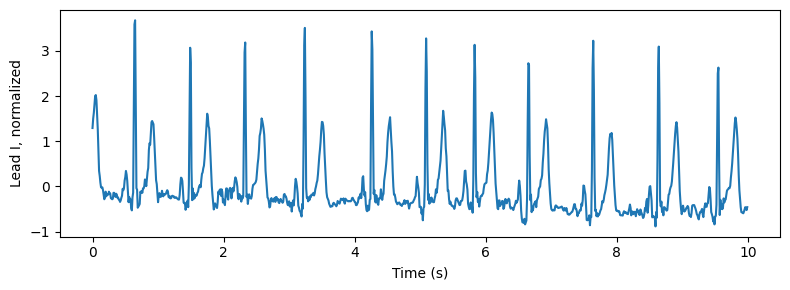

1 input: (12, 1000) target: [0.0, 0.0, 1.0, 0.0, 0.0]
2 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]
3 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]
4 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]
5 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]
6 input: (12, 1000) target: [0.0, 0.0, 1.0, 0.0, 0.0]
7 input: (12, 1000) target: [1.0, 0.0, 0.0, 0.0, 0.0]
CPU입니다. 특히 생성·검출·3D 분할은 Colab GPU 런타임에서 실행하는 편이 낫습니다.


In [21]:
#@title 6. 입력과 정답 확인
inspect_data(datasets)

#### A: epoch 3 15 30 학습과 비교

{'epoch': 1, 'train_loss': 0.5609407158851624, 'val_macro_f1': 0.0}
{'epoch': 2, 'train_loss': 0.48137424397468564, 'val_macro_f1': 0.24363451491672775}
{'epoch': 3, 'train_loss': 0.44628160529136657, 'val_macro_f1': 0.3649713143135443}


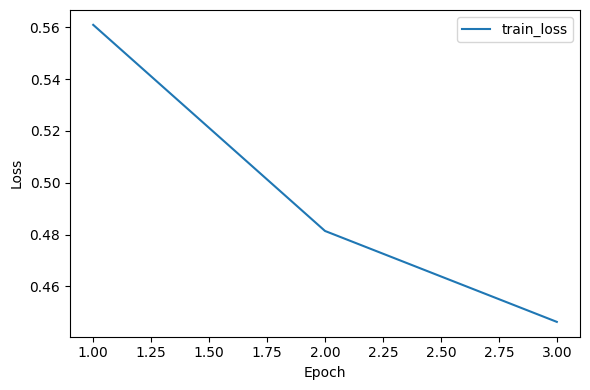

{
  "macro_f1": 0.40307139833830885,
  "exact_match_accuracy": 0.386,
  "macro_ovr_auroc": 0.8019191046887709,
  "auroc_by_class": {
    "NORM": 0.8576618548737508,
    "MI": 0.799141704944901,
    "STTC": 0.8233600484913793,
    "CD": 0.7874520576049604,
    "HYP": 0.7419798575288628
  },
  "threshold": 0.5,
  "quick_run": false,
  "test_samples": 1000,
  "validation_selected": true
}
{'epoch': 1, 'train_loss': 0.5609407158851624, 'val_macro_f1': 0.0}
{'epoch': 2, 'train_loss': 0.48137424397468564, 'val_macro_f1': 0.24363451491672775}
{'epoch': 3, 'train_loss': 0.44628160529136657, 'val_macro_f1': 0.3649713143135443}
{'epoch': 4, 'train_loss': 0.4194293489456177, 'val_macro_f1': 0.4856783376298561}
{'epoch': 5, 'train_loss': 0.40160782012939455, 'val_macro_f1': 0.4380458608432626}
{'epoch': 6, 'train_loss': 0.385714222240448, 'val_macro_f1': 0.5611066511469565}
{'epoch': 7, 'train_loss': 0.38004611673355104, 'val_macro_f1': 0.5413025340552626}
{'epoch': 8, 'train_loss': 0.368788205337

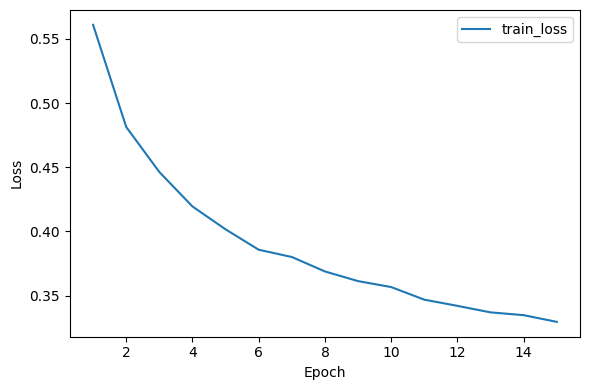

{
  "macro_f1": 0.6224276786055245,
  "exact_match_accuracy": 0.496,
  "macro_ovr_auroc": 0.8792615342950196,
  "auroc_by_class": {
    "NORM": 0.9096380694893706,
    "MI": 0.8536046235793924,
    "STTC": 0.8954685255028736,
    "CD": 0.867579258111027,
    "HYP": 0.8700171947924342
  },
  "threshold": 0.5,
  "quick_run": false,
  "test_samples": 1000,
  "validation_selected": true
}
{'epoch': 1, 'train_loss': 0.5609407158851624, 'val_macro_f1': 0.0}
{'epoch': 2, 'train_loss': 0.48137424397468564, 'val_macro_f1': 0.24363451491672775}
{'epoch': 3, 'train_loss': 0.44628160529136657, 'val_macro_f1': 0.3649713143135443}
{'epoch': 4, 'train_loss': 0.4194293489456177, 'val_macro_f1': 0.4856783376298561}
{'epoch': 5, 'train_loss': 0.40160782012939455, 'val_macro_f1': 0.4380458608432626}
{'epoch': 6, 'train_loss': 0.385714222240448, 'val_macro_f1': 0.5611066511469565}
{'epoch': 7, 'train_loss': 0.38004611673355104, 'val_macro_f1': 0.5413025340552626}
{'epoch': 8, 'train_loss': 0.3687882053375

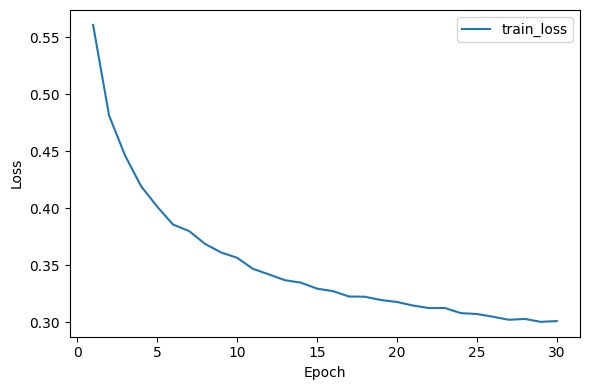

{
  "macro_f1": 0.6647995138236679,
  "exact_match_accuracy": 0.541,
  "macro_ovr_auroc": 0.8918699439249128,
  "auroc_by_class": {
    "NORM": 0.9223716184682729,
    "MI": 0.8751051303616485,
    "STTC": 0.9180809985632185,
    "CD": 0.8835021171589608,
    "HYP": 0.8602898550724637
  },
  "threshold": 0.5,
  "quick_run": false,
  "test_samples": 1000,
  "validation_selected": true
}
   epochs  best_epoch  val_macro_f1  test_macro_f1  test_macro_auroc  \
0       3           3        0.3650         0.4031            0.8019   
1      15          14        0.6206         0.6224            0.8793   
2      30          30        0.6544         0.6648            0.8919   

   test_exact_match  
0             0.386  
1             0.496  
2             0.541  
validation 기준 선택: 30 epochs


In [22]:
BASE_OUT = OUT
SETTINGS = [3, 15, 30]      # 바꾸는 한 가지 조건: EPOCHS
runs = {}
for ep in SETTINGS:
    seed_everything(SEED)   # 매번 같은 시작점
    EPOCHS = ep
    OUT = BASE_OUT / f'ep{ep}'; OUT.mkdir(parents=True, exist_ok=True)
    model, loaders = train_classifier(datasets)
    hist = pd.read_csv(OUT/'history.csv')
    b = hist.loc[hist['val_macro_f1'].idxmax()]
    test = evaluate_classifier(model, loaders)
    runs[ep] = dict(model=model, loaders=loaders, out=OUT, best_epoch=int(b['epoch']),
                    val_f1=float(b['val_macro_f1']), test=test)
OUT = BASE_OUT

summary = pd.DataFrame([{'epochs':ep,'best_epoch':r['best_epoch'],'val_macro_f1':r['val_f1'],
    'test_macro_f1':r['test']['macro_f1'],'test_macro_auroc':r['test']['macro_ovr_auroc'],
    'test_exact_match':r['test']['exact_match_accuracy']} for ep,r in runs.items()]).round(4)
summary.to_csv(BASE_OUT/'epoch_comparison.csv', index=False)
chosen = int(summary.loc[summary['val_macro_f1'].idxmax(), 'epochs'])
print(summary); print('validation 기준 선택:', chosen, 'epochs')

### B: 클래스별 혼동행렬

         FN             FP        
epochs   3    15   30   3   15  30
cls                               
CD      135  120  108   49  29  25
HYP     109   78   60    6  19  37
MI      191  119  119   23  51  39
NORM     99   98   69  125  74  86
STTC    183   68   82   28  85  47


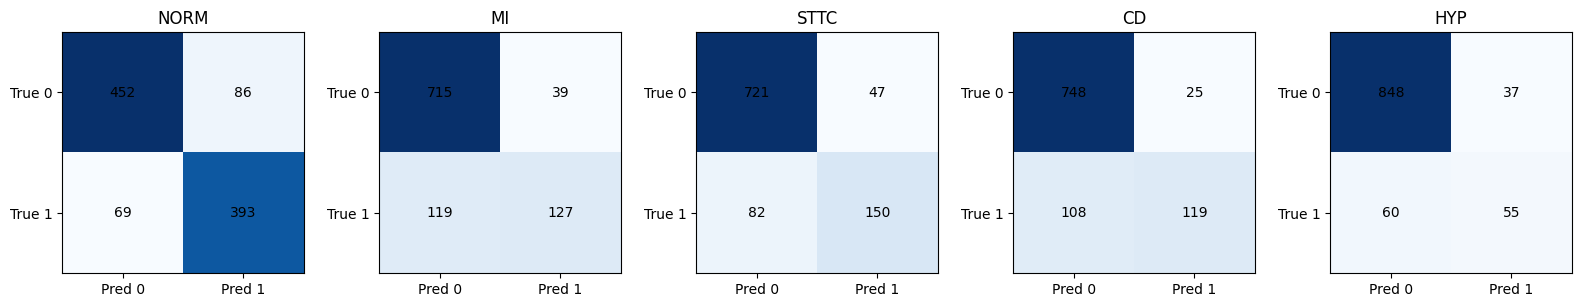

In [23]:
from sklearn.metrics import multilabel_confusion_matrix
rows = []
for ep, r in runs.items():
    y, p = classification_predict(r['model'], r['loaders']['test'])
    for name, cm in zip(CLASS_NAMES, multilabel_confusion_matrix(y, (p>=0.5).astype(int))):
        tn, fp, fn, tp = cm.ravel(); rows.append(dict(epochs=ep, cls=name, TP=tp, FN=fn, FP=fp, TN=tn))
print(pd.DataFrame(rows).pivot(index='cls', columns='epochs', values=['FN','FP']))

best = runs[chosen]
yt, pt = classification_predict(best['model'], best['loaders']['test'])
pred = (pt >= 0.5).astype(int)
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, cm, name in zip(axes, multilabel_confusion_matrix(yt, pred), CLASS_NAMES):
    ax.imshow(cm, cmap='Blues'); ax.set_title(name)
    for (i, j), v in np.ndenumerate(cm): ax.text(j, i, int(v), ha='center', va='center')
    ax.set_xticks([0,1], ['Pred 0','Pred 1']); ax.set_yticks([0,1], ['True 0','True 1'])
fig.tight_layout(); fig.savefig(best['out']/'confusion_by_class.png', dpi=120); plt.show()

### C셀: 실패사례

exact-match 실패: 459 / 1000
클래스별 놓친 사례(FN): {'NORM': 69, 'MI': 119, 'STTC': 82, 'CD': 108, 'HYP': 60}


/tmp/ipykernel_460/3215427395.py:22: UserWarning: Glyph 45459 (\N{HANGUL SYLLABLE NOH}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(best['out']/'failure_cases.png', dpi=120); plt.show()
/tmp/ipykernel_460/3215427395.py:22: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); fig.savefig(best['out']/'failure_cases.png', dpi=120); plt.show()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45459 (\N{HANGUL SYLLABLE NOH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52840 (\N{HANGUL SYLLABLE CIM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


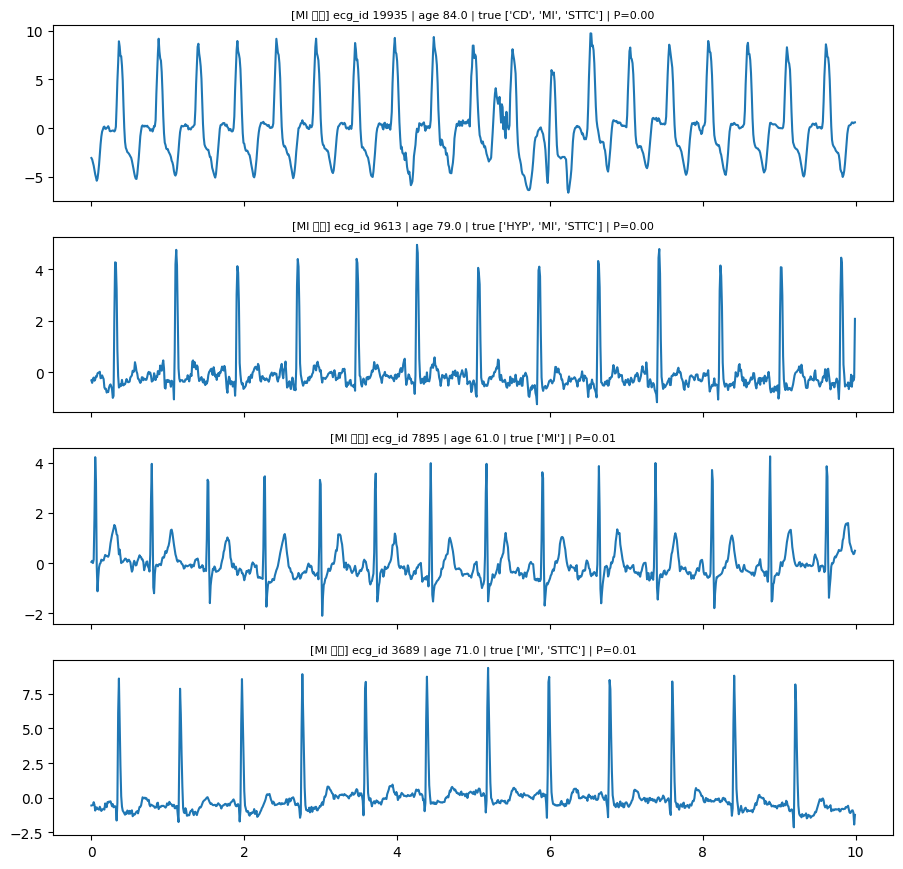

In [24]:
used = pd.read_csv(BASE_OUT/'used_samples.csv')
test_rows = used[used['split']=='test'].reset_index(drop=True)
meta = pd.read_csv(Path(DATA_ROOT)/'ptbxl_database.csv', index_col='ecg_id')
test_rows['ecg_id'] = test_rows['id'].astype(int)
test_rows = test_rows.join(meta[['age','sex']], on='ecg_id')

print('exact-match 실패:', int((pred != yt).any(axis=1).sum()), '/', len(yt))
fn_counts = ((yt==1) & (pred==0)).sum(axis=0)
print('클래스별 놓친 사례(FN):', dict(zip(CLASS_NAMES, fn_counts.tolist())))

k = int(fn_counts.argmax())
fn_idx = np.flatnonzero((yt[:,k]==1) & (pred[:,k]==0))
fn_idx = fn_idx[np.argsort(pt[fn_idx,k])][:4]   # 확률이 가장 낮았던(가장 확신 없이 놓친) 순
if len(fn_idx) == 0:
    print('놓친 사례가 없습니다.')
else:
    fig, axes = plt.subplots(len(fn_idx), 1, figsize=(9, 2.2*len(fn_idx)), sharex=True)
    for ax, i in zip(np.atleast_1d(axes), fn_idx):
        ax.plot(np.arange(1000)/100, datasets['test'].images[i][:,0])   # Lead I
        r = test_rows.iloc[i]
        ax.set_title(f"[{CLASS_NAMES[k]} 놓침] ecg_id {r['ecg_id']} | age {r['age']} | true {r['diagnoses']} | P={pt[i,k]:.2f}", fontsize=8)
    fig.tight_layout(); fig.savefig(best['out']/'failure_cases.png', dpi=120); plt.show()

### D: 결과저장

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
shutil.copytree(BASE_OUT, '/content/drive/MyDrive/ptbxl_classroom_results', dirs_exist_ok=True)
result_zip = export_result_bundle()   # ZIP도 내 컴퓨터로 다운로드

## 10. 학생 확장 과제
동일한 분할을 고정하고 입력 해상도 또는 학습량 하나만 변경하세요. validation으로 설정을 선택하고 test 지표·혼동행렬·실패 사례를 비교하세요.

실험 제목 / 변경한 한 가지 조건 / 분할·해상도 / validation 선택 기준 / test 결과 / 실패 사례를 보고하세요.